# Primary Model

## Purged Validation

- **Purpose:** Apply `purged_validation.py`'s `PurgedKFold` directly to the development partition.
- **Settings:** `cv=5` contiguous folds; `pct_embargo=0.01`; `random_state=42`; labels = {-1, 1}; sealed chronological holdout.
- **Data:** Use development features, direction labels, sample weights, and event information intervals.
- **Findings:**
- **Decision:** Purge overlapping intervals, exclude holdout from every fold, and minimize weighted log loss with weighted F1 used only for exact ties.

In [1]:
from pathlib import Path

from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")

import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[2]

from src.modeling.purged_validation import PurgedKFold
from src.modeling.model_workflow import (
    build_model_evaluation_table,
    build_primary_model_frame,
    compute_stage_importance,
    finalize_primary_model,
    get_primary_feature_columns,
    plot_feature_importance,
    plot_learning_curves,
    plot_model_evaluation,
    run_model_selection_workflow,
)
from src.preprocessing.market_data import ResearchPaths

RANDOM_STATE = 42
CV_SPLITS = 5
PCT_EMBARGO = 0.01
TRAIN_SIZES = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
PERIOD = "2025-02-01_2025-12-31"
PARAMETER_GRIDS = {
    "boosting": {
        "model__n_estimators": [100, 200],
        "model__estimator__max_depth": [2, 5],
        "model__learning_rate": [0.03, 0.1],
    },
    "bagging": {
        "model__n_estimators": [100, 200],
        "model__estimator__max_depth": [2, 5],
        "model__max_samples": [0.4, 0.8],
        "model__max_features": [0.4, 0.8],
    },
    "random_forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [2, 5],
        "model__max_samples": [0.4, 0.8],
        "model__max_features": [0.1, 0.2],
    },
}
paths = ResearchPaths(PROJECT_ROOT, model_kind="market", period=PERIOD)
event_path = paths.event("model")
artifact_dir = PROJECT_ROOT / "data/modeling/market"
artifact_dir.mkdir(parents=True, exist_ok=True)

events = pd.read_parquet(event_path).sort_values("event_start", ignore_index=True)
development_starts = events.loc[
    events["partition"].eq("development"), ["symbol", "event_start"]
]
holdout_starts = events.loc[
    events["partition"].eq("holdout"), ["symbol", "event_start"]
]
development = build_primary_model_frame(events, development_starts, model_kind="market")
holdout = build_primary_model_frame(events, holdout_starts, model_kind="market")
feature_columns = get_primary_feature_columns(development, model_kind="market")

X_development = development[feature_columns]
y_development = development["direction_label"].astype("int8")
w_development = development["sample_weight"].astype("float64")
t1_development = development["event_end"]
CLASS_LABELS = [-1, 1]
STAGE_SCORING = "neg_log_loss"

cv = PurgedKFold(CV_SPLITS, t1=t1_development, pct_embargo=PCT_EMBARGO)
fold_assignment = pd.Series(pd.NA, index=X_development.index, dtype="Int64", name="cv_fold")
fold_rows = []
for fold, (train, test) in enumerate(cv.split(X_development)):
    fold_assignment.iloc[test] = fold
    fold_rows.append({
        "fold": fold,
        "train_events": len(train),
        "test_events": len(test),
        "test_start": t1_development.index.get_level_values("event_start")[test].min(),
        "test_end": t1_development.iloc[test].max(),
    })

split_manifest = events[[
    "symbol", "event_start", "event_end", "partition", "holdout_boundary"
]].merge(
    fold_assignment.reset_index(),
    on=["symbol", "event_start"],
    how="left",
    validate="one_to_one",
)
split_manifest.to_parquet(artifact_dir / "split_manifest.parquet", index=False)
display(pd.DataFrame(fold_rows).set_index("fold"))
display(pd.Series({
    "development_events": len(development),
    "holdout_events": len(holdout),
    "features": len(feature_columns),
}, name="value").to_frame())

,train_events,test_events,test_start,test_end
fold,,,,
0,11344,2882,2025-02-03 14:30:00.009395+00:00,2025-04-02 16:54:06.660953+00:00
1,11027,2882,2025-04-02 14:13:38.147152+00:00,2025-05-06 18:38:13.769528+00:00
2,11290,2881,2025-05-02 13:30:03.066935+00:00,2025-07-10 16:38:14.868445+00:00
3,11335,2881,2025-07-10 14:37:39.034456+00:00,2025-09-03 17:45:21.507708+00:00
4,11515,2881,2025-09-03 13:30:00.864600+00:00,2025-10-24 13:50:57.771170+00:00


,value
development_events,14407
holdout_events,3565
features,49


## Ensemble Methods

- **Purpose:** Compare all AdaBoost, Bagging, and Random Forest configurations and select the best candidate per family and overall.
- **Settings:** Notebook-owned grids: 27 AdaBoost, 81 Bagging, 81 RF configurations; max_depth=[2, 5, 10] for all families; library-default leaf size; AdaBoost class_weight=None, Bagging class_weight=balanced, RF class_weight=balanced_subsample; entropy trees; cv=5; embargo 1%; seed 42; n_jobs=1; OOB disabled.
- **Data:** Generate sample-weighted purged development OOF predictions for every configuration; display the full search and family winners.
- **Findings:**
- **Decision:** Select by minimum weighted OOF log loss, then maximum weighted F1; exact ties retain family and grid order. Holdout remains excluded.


In [2]:
selection_result = run_model_selection_workflow(
    X_development,
    y_development,
    w_development,
    t1_development,
    scoring=STAGE_SCORING,
    cv=CV_SPLITS,
    pct_embargo=PCT_EMBARGO,
    random_state=RANDOM_STATE,
    n_jobs=1,
    candidate_settings={name: {} for name in PARAMETER_GRIDS},
    parameter_grids=PARAMETER_GRIDS,
    show_progress=True,
)
candidates = selection_result.estimators
candidate_oof = selection_result.oof_predictions
final_name = selection_result.selected_name
final_configuration = selection_result.final_configuration
final_estimator = selection_result.final_estimator
final_oof = selection_result.final_oof
display(selection_result.tuning)
display(selection_result.comparison.rename(index=lambda name: name.replace("_", " ").title()))
print(f"Selected family: {final_name}; configuration: {final_configuration}")


Ensemble search:   0%|          | 0/200 [00:00<?, ?it/s]

,candidate,configuration,model__estimator__max_depth,model__learning_rate,model__n_estimators,log_loss,accuracy,f1,precision,recall,model__max_features,model__max_samples,model__max_depth
0,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.03,100,0.722805,0.614955,0.620086,0.597824,0.644069,NaN,NaN,NaN
1,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.03,200,0.696729,0.615375,0.620522,0.598213,0.644560,NaN,NaN,NaN
2,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.10,100,0.682222,0.615511,0.617666,0.599848,0.636574,NaN,NaN,NaN
3,boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.10,200,0.670774,0.615332,0.619186,0.598819,0.640988,NaN,NaN,NaN
4,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.03,100,0.708242,0.613185,0.614816,0.597867,0.632753,NaN,NaN,NaN
5,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.03,200,0.685595,0.609411,0.611384,0.594058,0.629750,NaN,NaN,NaN
6,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.10,100,0.677574,0.610729,0.611487,0.595912,0.627897,NaN,NaN,NaN
7,boosting,"{'model__estimator__max_depth': 5, 'model__lea...",5.0,0.10,200,0.675086,0.606667,0.607467,0.591947,0.623822,NaN,NaN,NaN
8,bagging,"{'model__estimator__max_depth': 2, 'model__max...",2.0,NaN,100,0.662577,0.614271,0.611042,0.601380,0.621020,0.4,0.4,NaN
9,bagging,"{'model__estimator__max_depth': 2, 'model__max...",2.0,NaN,200,0.662383,0.613458,0.610580,0.600391,0.621120,0.4,0.4,NaN


,configuration,model__estimator__max_depth,model__learning_rate,model__n_estimators,log_loss,accuracy,f1,precision,recall,model__max_features,model__max_samples,model__max_depth
candidate,,,,,,,,,,,,
Boosting,"{'model__estimator__max_depth': 2, 'model__lea...",2.0,0.1,200,0.670774,0.615332,0.619186,0.598819,0.640988,NaN,NaN,NaN
Bagging,"{'model__estimator__max_depth': 2, 'model__max...",2.0,NaN,200,0.662383,0.613458,0.610580,0.600391,0.621120,0.4,0.4,NaN
Random Forest,"{'model__max_depth': 2, 'model__max_features':...",NaN,NaN,200,0.661564,0.613300,0.625308,0.592970,0.661376,0.2,0.4,2.0


Selected family: random_forest; configuration: {'model__max_depth': 2, 'model__max_features': 0.2, 'model__max_samples': 0.4, 'model__n_estimators': 200}


## Learning Curves

- **Purpose:** Diagnose each family's best estimator with the same weighted learning-curve helper.
- **Settings:** `train_sizes=(0.10,0.20,...,1.00); 10 points; 1x3 layout`; stratified subsets; `cv=5`; embargo 1%; seed 42; error = weighted log loss, mean ± standard error.
- **Data:** Build each family winner's learning curve from development folds only.
- **Findings:**
- **Decision:** Do not revise the model or grid from holdout learning behavior.

Learning curves:   0%|          | 0/150 [00:00<?, ?it/s]

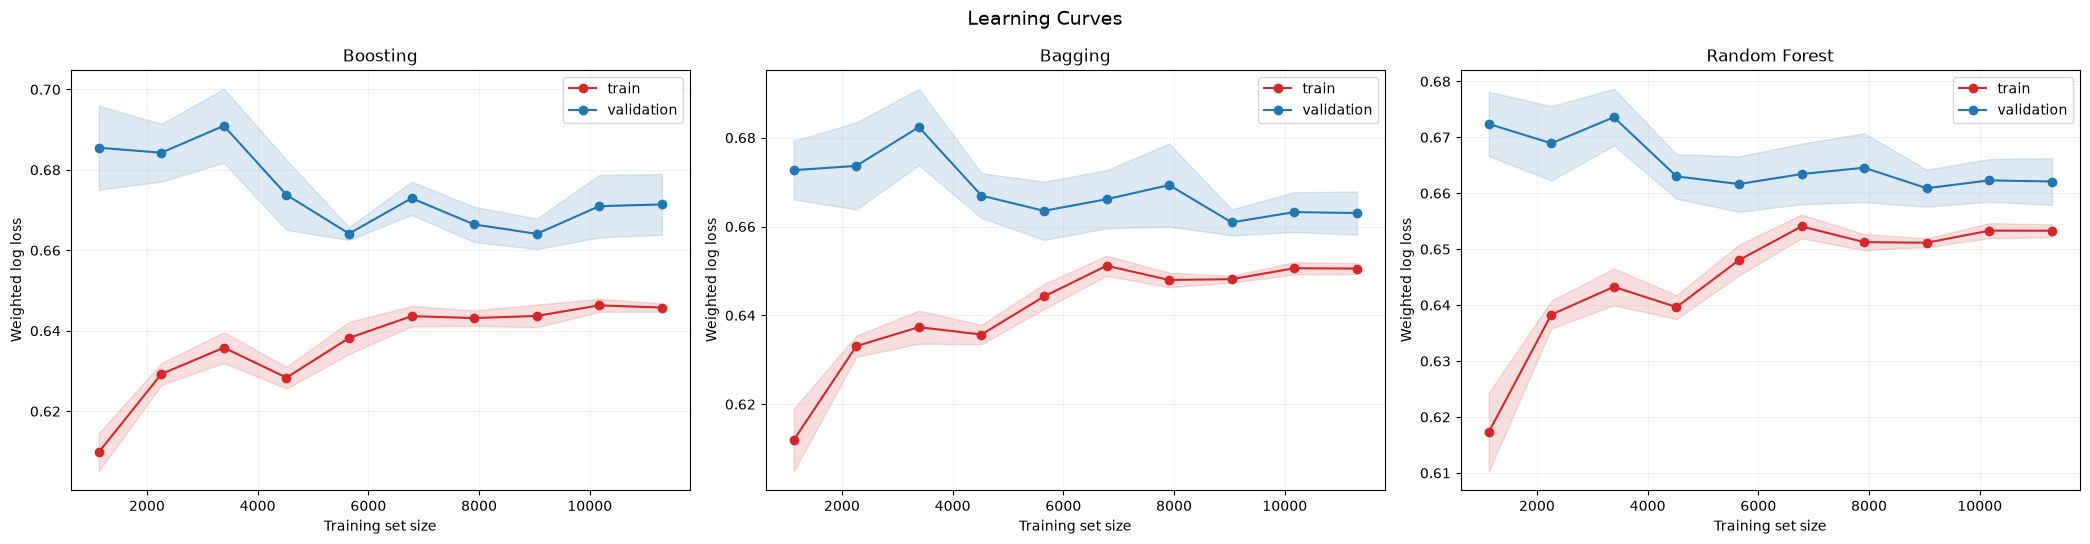

{'boosting':    train_fraction  train_size  train_error_mean  train_error_std  \
 0             0.1        1130          0.609811         0.004761   
 1             0.2        2260          0.629242         0.002742   
 2             0.3        3390          0.635802         0.003816   
 3             0.4        4521          0.628346         0.002712   
 4             0.5        5651          0.638208         0.004015   
 5             0.6        6781          0.643639         0.002550   
 6             0.7        7911          0.643152         0.001911   
 7             0.8        9042          0.643695         0.002825   
 8             0.9       10172          0.646322         0.001624   
 9             1.0       11302          0.645776         0.001034   
 
    validation_error_mean  validation_error_std  
 0               0.685504              0.010437  
 1               0.684266              0.007186  
 2               0.690959              0.009170  
 3               0.673781  

In [3]:
plot_learning_curves(
    candidates,
    "Learning Curves",
    features=X_development,
    labels=y_development,
    sample_weight=w_development,
    cv=cv,
    train_sizes=TRAIN_SIZES,
    class_labels=CLASS_LABELS,
    positive_label=1,
    scoring=STAGE_SCORING,
    random_state=RANDOM_STATE,
    show_progress=True,
)

## Feature Importance

- **Purpose:** Apply the same estimator-aware MDI, MDA, and SFI methods to each family’s best candidate.
- **Settings:** `cv=5`; `pct_embargo=0.01`; `random_state=42`; `top_k=15`; MDI/MDA/SFI in one row per family; MDA and SFI use weighted negative log loss.
- **Data:** Calculate and preserve family-winner importance results for all 49 primary features.
- **Findings:**
- **Decision:** Treat importance as a diagnostic rather than feature selection.

MDI importance:   0%|          | 0/6 [00:00<?, ?it/s]

MDA importance:   0%|          | 0/250 [00:00<?, ?it/s]

SFI importance:   0%|          | 0/250 [00:00<?, ?it/s]

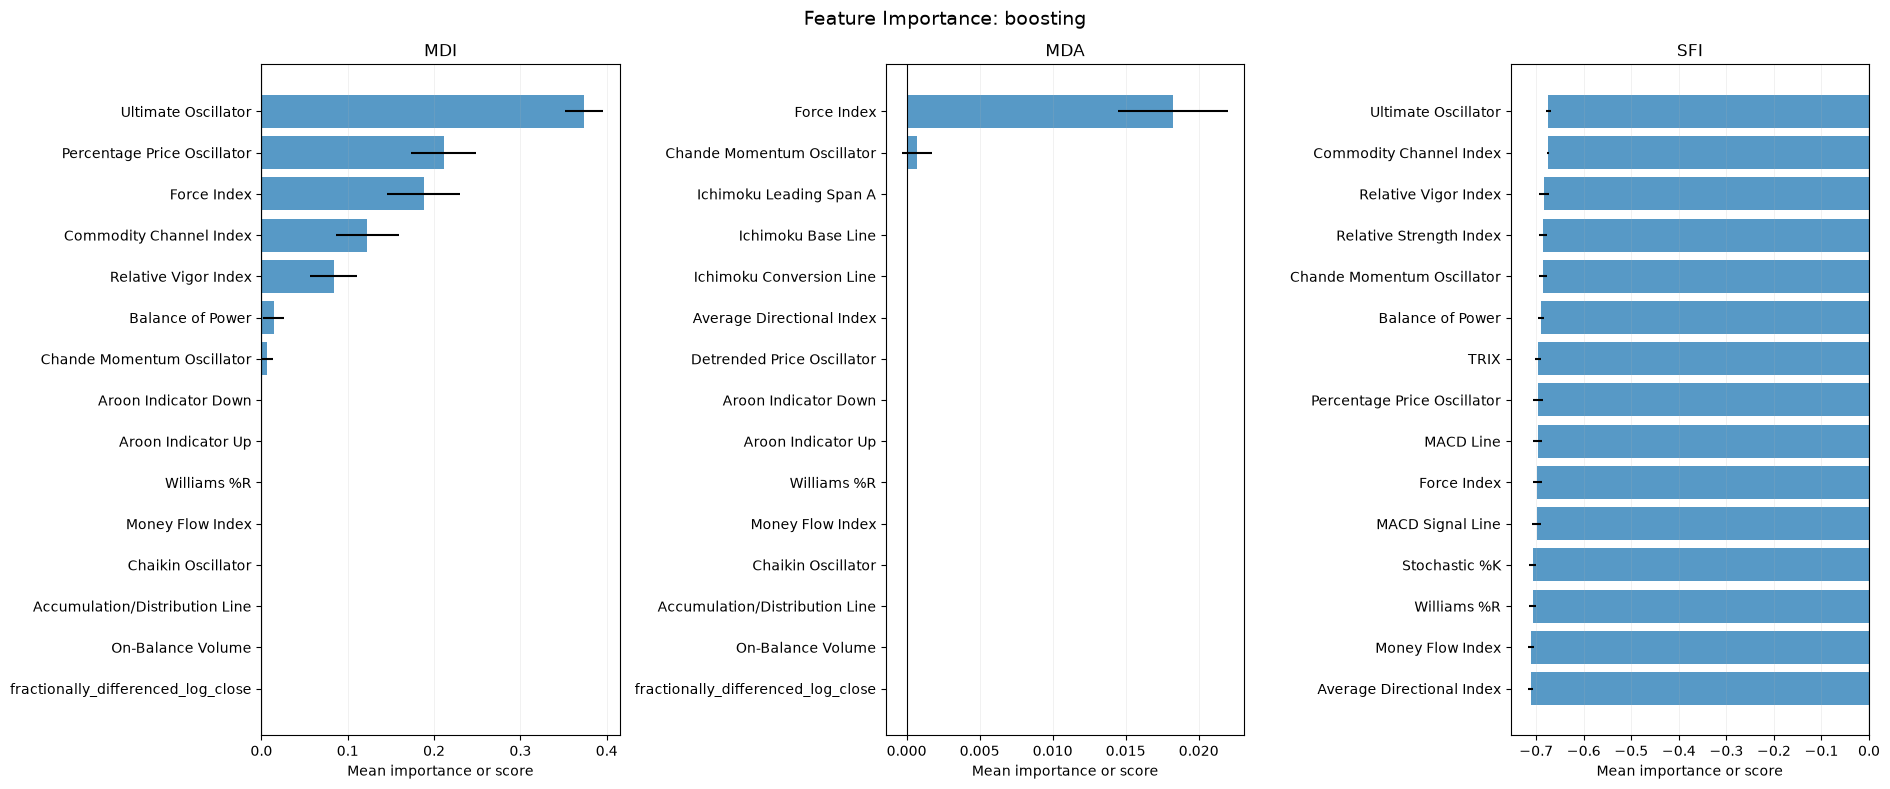

,mdi,mda,sfi_neg_log_loss
Force Index,0.187961,0.018237,-0.697856
Chande Momentum Oscillator,0.006878,0.000732,-0.686288
fractionally_differenced_log_close,0.000000,0.000000,-0.731674
Pivot Point Support 1,0.000000,0.000000,-0.718833
Double Exponential Moving Average (DEMA),0.000000,0.000000,-0.732041
Triangular Moving Average,0.000000,0.000000,-0.718827
Weighted Moving Average (WMA),0.000000,0.000000,-0.721232
Hull Moving Average (HMA),0.000000,0.000000,-0.736084
Volume Weighted Average Price (VWAP),0.000000,0.000000,-0.732700
Parabolic SAR,0.000000,0.000000,-0.720020


MDI importance:   0%|          | 0/6 [00:00<?, ?it/s]

MDA importance:   0%|          | 0/250 [00:00<?, ?it/s]

SFI importance:   0%|          | 0/250 [00:00<?, ?it/s]

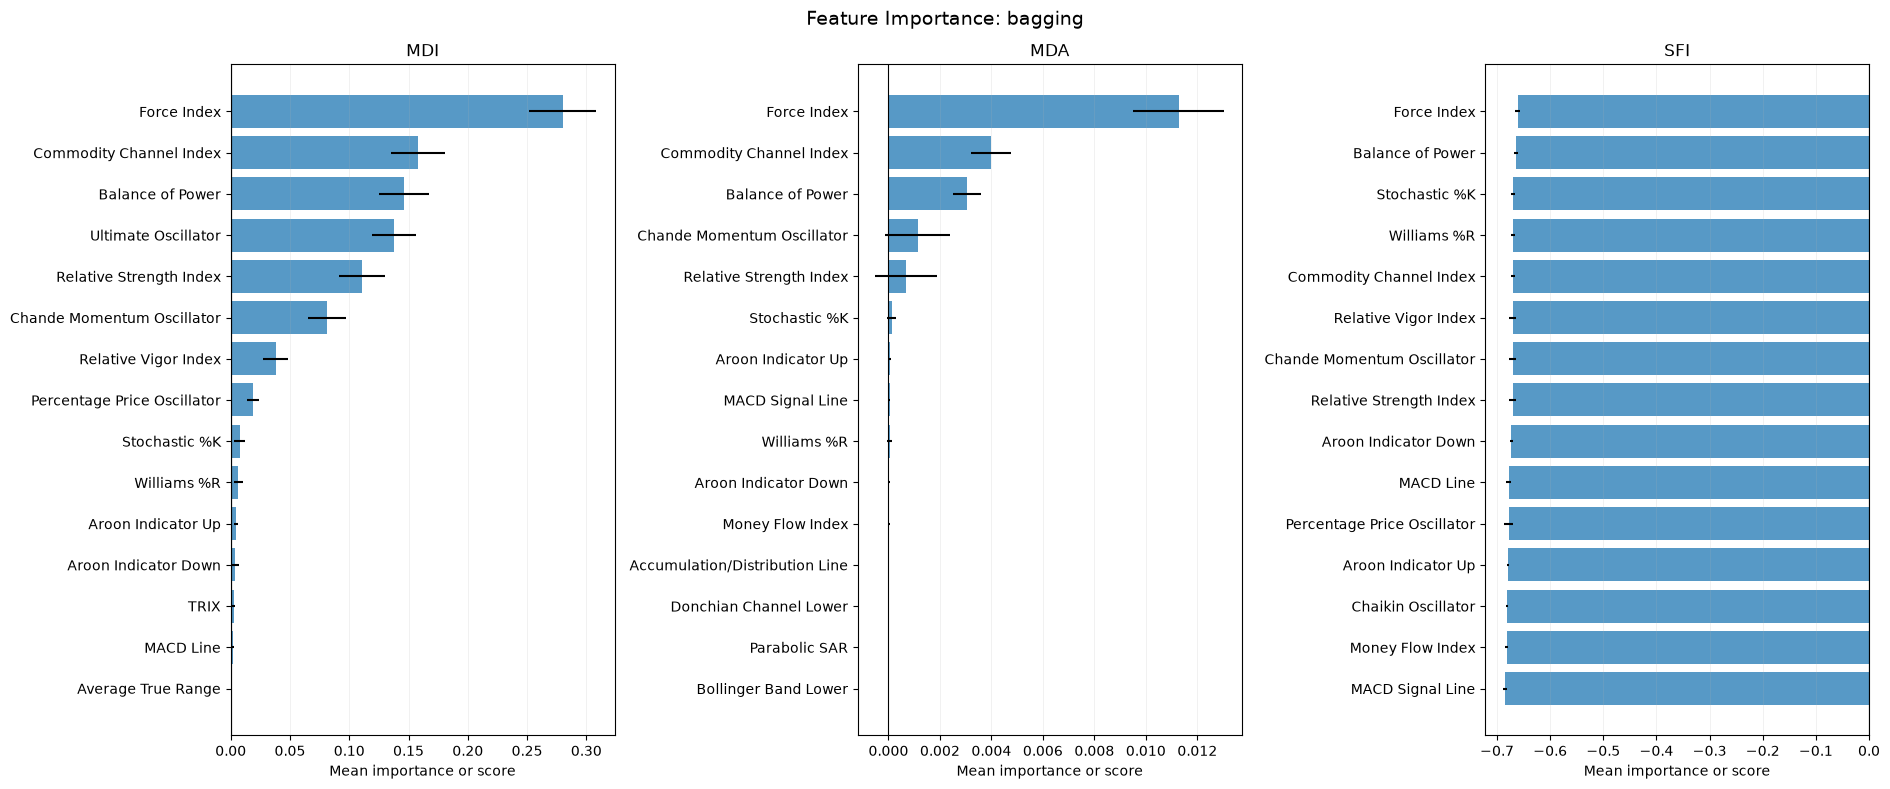

,mdi,mda,sfi_neg_log_loss
Force Index,0.280115,0.011269,-0.661286
Commodity Channel Index,0.158024,0.003985,-0.669865
Balance of Power,0.146000,0.003046,-0.664328
Chande Momentum Oscillator,0.081096,0.001147,-0.670775
Relative Strength Index,0.110583,0.000696,-0.670776
Stochastic %K,0.007500,0.000126,-0.669562
Aroon Indicator Up,0.004789,0.000062,-0.679700
MACD Signal Line,0.000000,0.000046,-0.684329
Williams %R,0.006385,0.000043,-0.669562
Aroon Indicator Down,0.003670,0.000035,-0.672875


MDI importance:   0%|          | 0/6 [00:00<?, ?it/s]

MDA importance:   0%|          | 0/250 [00:00<?, ?it/s]

SFI importance:   0%|          | 0/250 [00:00<?, ?it/s]

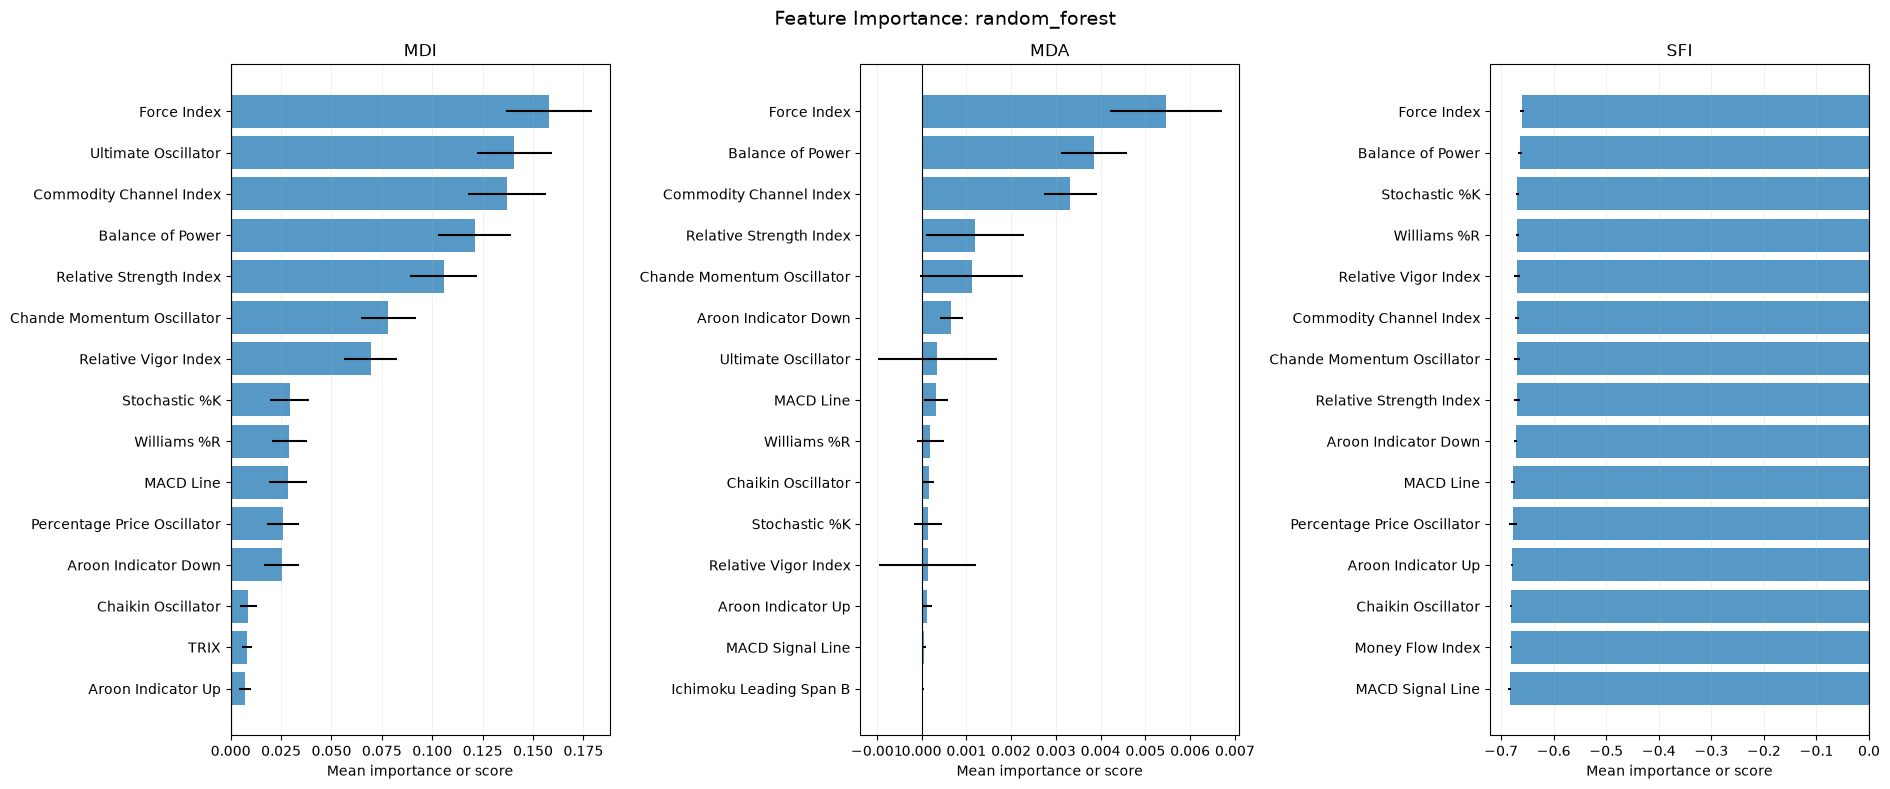

,mdi,mda,sfi_neg_log_loss
Force Index,0.157853,0.005463,-0.660651
Balance of Power,0.121097,0.003858,-0.663656
Commodity Channel Index,0.137085,0.003326,-0.669733
Relative Strength Index,0.105601,0.001195,-0.670160
Chande Momentum Oscillator,0.078275,0.001116,-0.670159
Aroon Indicator Down,0.025229,0.000664,-0.672159
Ultimate Oscillator,0.140600,0.000355,-0.696707
MACD Line,0.028442,0.000316,-0.676925
Williams %R,0.029069,0.000195,-0.668897
Chaikin Oscillator,0.008684,0.000156,-0.680437


,boosting,bagging,random_forest
MDI,-0.671414,-0.663044,-0.662095
MDA,-0.671414,-0.663044,-0.662095
SFI,-0.671414,-0.663044,-0.662095


In [4]:
importance_scores = {}
for name, estimator in candidates.items():
    results, scores = compute_stage_importance(
        estimator,
        features=X_development,
        labels=y_development,
        sample_weight=w_development,
        information_sets=t1_development,
        scoring=STAGE_SCORING,
        cv=CV_SPLITS,
        pct_embargo=PCT_EMBARGO,
        random_state=RANDOM_STATE,
        show_progress=True,
    )
    importance_scores[name] = scores
    plot_feature_importance(results, f"Feature Importance: {name}")
    importance = pd.DataFrame({
        "mdi": results["MDI"]["mean"],
        "mda": results["MDA"]["mean"],
        "sfi_neg_log_loss": results["SFI"]["mean"],
    }).sort_values("mda", ascending=False)
    display(importance.head(15))
display(pd.DataFrame(importance_scores))

## Model Evaluation

- **Purpose:** Compare each family’s best candidate’s accuracy, precision, recall, F1, log loss, and diagnostic curves on development OOF predictions; confusion matrices in one row and overlaid PR/ROC side by side.
- **Settings:** Labels = {-1, 1}; positive label = 1; sample-weighted metrics, confusion matrices, PR/AP and ROC/AUC.
- **Data:** Use development OOF results, then persist the model and prediction provenance.
- **Findings:**
- **Decision:** Fix the configuration from development OOF; holdout predictions are saved without displaying holdout evaluation.

,accuracy,precision,recall,f1,log_loss
model,,,,,
Boosting,0.615332,0.598819,0.640988,0.619186,0.670774
Bagging,0.613458,0.600391,0.621120,0.610580,0.662383
Random Forest,0.613300,0.592970,0.661376,0.625308,0.661564


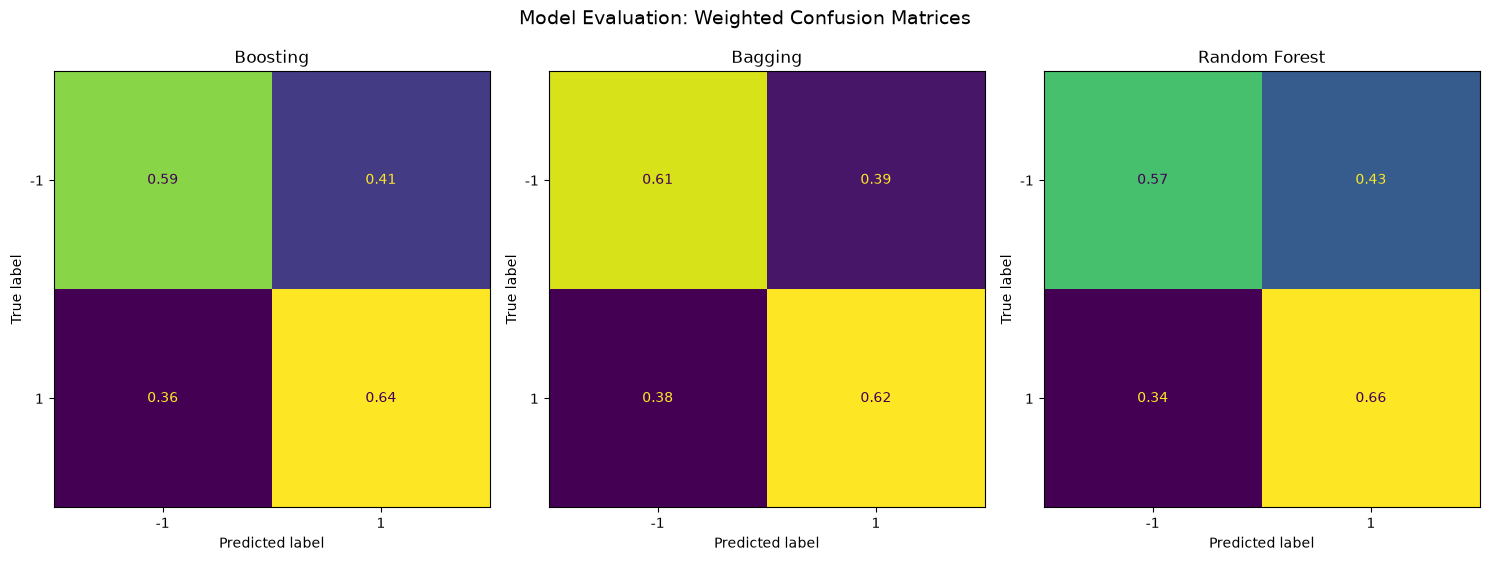

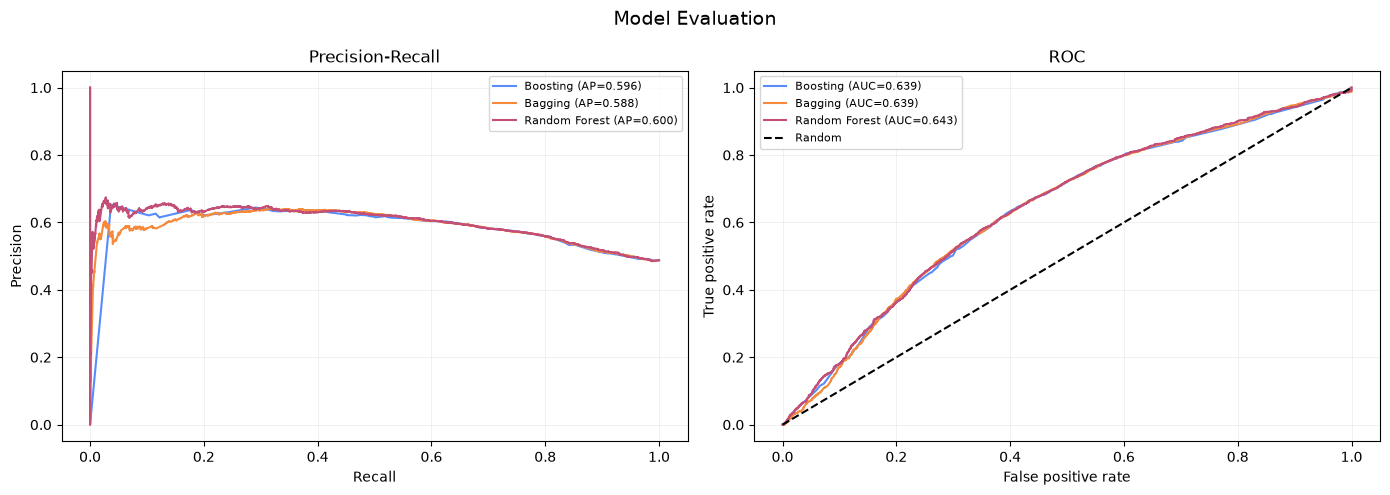

Final primary model:   0%|          | 0/4 [00:00<?, ?it/s]

/Users/kwonjunhyuk9/Documents/financial-machine-learning/data/modeling/market/primary_model.joblib


In [5]:
display(build_model_evaluation_table(
    candidate_oof,
    y_development,
    w_development,
    class_labels=CLASS_LABELS,
    positive_label=1,
))

plot_model_evaluation(
    candidate_oof,
    y_development,
    w_development,
    "Model Evaluation",
    class_labels=CLASS_LABELS,
    positive_label=1,
)

primary_predictions = finalize_primary_model(
    development,
    holdout,
    estimator=final_estimator,
    final_oof=final_oof,
    feature_columns=feature_columns,
    artifact_dir=artifact_dir,
    selected_candidate=final_name,
    best_configuration=final_configuration,
    random_state=RANDOM_STATE,
    show_progress=True,
)

print(artifact_dir / "primary_model.joblib")